# Group 2: DSC 288 Capstone — Google Analytics Session Revenue Prediction

**Course:** DSC 288R Capstone  
**Team:** Justin Chanthabandith · Jinxin Xiao · Pooja Panchal  
**Dataset:** Google Analytics Customer Revenue Prediction (Kaggle)  


## 1. Background

### Problem Statement
The goal is to predict **session-level customer revenue** from Google Analytics data.
Most sessions produce zero revenue (~98–99%), creating a severely zero-inflated regression target.

**Input:** Session-level feature vector (traffic source, device, geography, session engagement signals, temporal features)  
**Output:** Predicted log1p-transformed transaction revenue per session

### Other Possible Predictive Tasks
The dataset also supports:
- **Binary purchase classification** — predict whether a session produces any revenue (has_revenue = 0/1)
- **Visitor-level lifetime value prediction** — aggregate revenue across all sessions per visitor
- **Channel attribution modeling** — predict which traffic channel drives the most revenue

We chose session-level revenue regression because it directly supports per-session targeting decisions
(e.g., bid adjustments in paid search), and because the zero-inflated structure makes it a representative
benchmark for comparing single-stage vs. two-step architectures.


---
## 2. Setup


In [1]:
%pip install -q polars pandas numpy scikit-learn matplotlib xgboost lightgbm


Note: you may need to restart the kernel to use updated packages.


### 2.1 Imports and Class Definitions

The `DataProcessor` and `TwoStageRevenueModel` classes are copied inline from `final.py` for portability.


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

### 2.2 Helper Functions


In [3]:
def safe_json(x):
    try:
        return json.loads(x)
    except:
        return {}


def column_split(df):
    device = pd.json_normalize(df['device'])
    device = device[['isMobile', 'deviceCategory']]

    geo = pd.json_normalize(df['geoNetwork'])
    geo = geo[['subContinent', 'country']]

    totals = pd.json_normalize(df['totals'])
    totals = totals.rename(columns={'hits': 'hit'})
    keep_totals = ['visits', 'hit', 'pageviews', 'transactions', 'transactionRevenue']
    totals = totals[keep_totals].apply(pd.to_numeric, errors='coerce')

    df_new = pd.concat([
        df.drop(columns=['device', 'geoNetwork', 'totals', 'trafficSource']),
        device, geo, totals
    ], axis=1)
    return df_new


def is_revenue(dataset):
    df = dataset.copy()
    df['transactionRevenue'] = pd.to_numeric(df['transactionRevenue'], errors='coerce').fillna(0)
    df['transactions'] = pd.to_numeric(df['transactions'], errors='coerce').fillna(0)
    df['has_revenue'] = (df['transactionRevenue'] > 0).astype(int)
    return df


def type_change(df):
    df['visitNumber'] = pd.to_numeric(df['visitNumber'], errors='coerce')
    df['visitStartTime'] = pd.to_datetime(df['visitStartTime'], unit='s')
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    return df

print('Helper functions defined')


Helper functions defined


### 2.3 DataProcessor Class


In [4]:
class DataProcessor:
    def __init__(self, path_file=None):
        self.X_train = self.X_val = self.X_test = None
        self.y_train = self.y_val = self.y_test = None
        self.y_train_reg = self.y_val_reg = self.y_test_reg = None
        if path_file is None:
            self.data = None
        else:
            self.data = self.get_data(path_file)
            self.split_data()

    def get_data(self, file_path, keep_cols=None, slice_iters=1_000_000):
        if keep_cols is None:
            keep_cols = ['fullVisitorId', 'channelGrouping', 'device', 'geoNetwork',
                         'trafficSource', 'visitNumber', 'visitStartTime', 'date', 'totals']

        df_pl = pl.scan_csv(file_path, schema_overrides={'fullVisitorId': pl.Utf8})
        features = list(set(keep_cols) & set(df_pl.collect_schema().names()))
        if not features:
            print('No matching features!')
            return

        df_pl = df_pl.select(features)
        all_chunks, count = [], 0
        for chunk in df_pl.collect(engine='streaming').iter_slices(slice_iters):
            chunk_pd = chunk.to_pandas()
            for col in ['device', 'geoNetwork', 'totals']:
                if col in chunk_pd.columns:
                    chunk_pd[col] = chunk_pd[col].apply(safe_json)
            chunk_pd = column_split(chunk_pd)
            count += len(chunk_pd)
            all_chunks.append(chunk_pd)

        data = pd.concat(all_chunks, axis=0)
        data = is_revenue(data)
        data = type_change(data)
        print(f'Loaded {data.shape[0]:,} rows, {data.shape[1]} columns')
        return data

    def split_data(self, features=None):
        if features is None:
            features = ['channelGrouping', 'visitNumber', 'isMobile', 'deviceCategory',
                        'subContinent', 'country', 'year', 'month', 'day', 'hit', 'pageviews']

        users = self.data['fullVisitorId'].unique()
        np.random.shuffle(users)
        n = len(users)
        train_users = users[:int(0.8 * n)]
        val_users   = users[int(0.8 * n):int(0.9 * n)]
        test_users  = users[int(0.9 * n):]

        train_df = self.data[self.data.fullVisitorId.isin(train_users)]
        val_df   = self.data[self.data.fullVisitorId.isin(val_users)]
        test_df  = self.data[self.data.fullVisitorId.isin(test_users)]

        features = list(set(features) & set(self.data.columns))
        self.X_train = train_df[features].copy()
        self.X_val   = val_df[features].copy()
        self.X_test  = test_df[features].copy()

        self.y_train = train_df['has_revenue']
        self.y_val   = val_df['has_revenue']
        self.y_test  = test_df['has_revenue']
        cat_cols = ['channelGrouping', 'deviceCategory', 'subContinent', 'country']
        for col in cat_cols:
            for split in [self.X_train, self.X_val, self.X_test]:
                if col in split.columns:
                    split[col] = split[col].astype('category')
        for split in [self.X_train, self.X_val, self.X_test]:
            if 'isMobile' in split.columns:
                split['isMobile'] = split['isMobile'].astype(float).fillna(0).astype(int)

        self.y_train_reg = np.log1p(train_df['transactionRevenue'])
        self.y_val_reg   = np.log1p(val_df['transactionRevenue'])
        self.y_test_reg  = np.log1p(test_df['transactionRevenue'])

        print(f'Train: {len(self.X_train):,} rows | Val: {len(self.X_val):,} | Test: {len(self.X_test):,}')
        print(f'Train positive rate: {self.y_train.mean():.4%}')

### 2.4 TwoStageRevenueModel Class


In [5]:
class TwoStageRevenueModel:
    def __init__(self, model_type='lgb', clf_params=None, reg_params=None, threshold=0.5):
        if model_type not in ('lgb', 'xgb'):
            raise ValueError(f"model_type must be 'lgb' or 'xgb', got '{model_type}'")
        self.model_type = model_type
        self.threshold = threshold

        if model_type == 'lgb':
            self.clf_params = clf_params or {
                'objective': 'binary', 'boosting_type': 'gbdt',
                'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31,
                'max_depth': -1, 'subsample': 0.8, 'colsample_bytree': 0.8,
                'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1
            }
            self.reg_params = reg_params or {
                'objective': 'regression', 'n_estimators': 500, 'learning_rate': 0.05,
                'num_leaves': 64, 'max_depth': 6, 'min_child_samples': 100,
                'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1,
                'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1
            }
            self.clf = lgb.LGBMClassifier(**self.clf_params)
            self.reg = lgb.LGBMRegressor(**self.reg_params)
        else:
            self.clf_params = clf_params or {
                'objective': 'binary:logistic', 'n_estimators': 300,
                'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8,
                'colsample_bytree': 0.8, 'scale_pos_weight': 10,
                'enable_categorical': True, 'random_state': 42, 'n_jobs': -1
            }
            self.reg_params = reg_params or {
                'objective': 'reg:squarederror', 'n_estimators': 500,
                'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 100,
                'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1,
                'reg_lambda': 1.0, 'enable_categorical': True, 'random_state': 42, 'n_jobs': -1
            }
            self.clf = xgb.XGBClassifier(**self.clf_params)
            self.reg = xgb.XGBRegressor(**self.reg_params)

    def fit(self, X, y_cls, y_reg):
        self.clf.fit(X, y_cls)
        buyer_mask = y_cls == 1
        self.reg.fit(X[buyer_mask], y_reg[buyer_mask])

    def predict_proba(self, X):
        return self.clf.predict_proba(X)[:, 1]

    def predict_expected_revenue(self, X):
        p_buy = self.predict_proba(X)
        rev = self.reg.predict(X)
        return p_buy * rev  

    def evaluate_classification(self, X, y):
        return roc_auc_score(y, self.predict_proba(X))

    def evaluate_regression(self, X, y):
        pred = self.predict_expected_revenue(X)
        return float(np.sqrt(mean_squared_error(y, pred)))

---
## 3. Data Loading

Polars is used for memory-safe streaming of the large CSV (~1.7M rows). Nested JSON columns
(`device`, `geoNetwork`, `totals`) are parsed via `json.loads` + `pd.json_normalize`.
Feature set is extended to include session engagement signals (`hit`, `pageviews`) beyond the
default configuration.


In [6]:
DATA_PATH = './data/train_v2.csv'

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(f'{DATA_PATH} not found. Download from Kaggle first.')

dp = DataProcessor()
dp.data = dp.get_data(DATA_PATH)

np.random.seed(42)
dp.split_data(features=[
    'channelGrouping', 'visitNumber', 'isMobile', 'deviceCategory',
    'subContinent', 'country', 'year', 'month', 'day', 'hit', 'pageviews'
])


Loaded 1,708,337 rows, 18 columns
Train: 1,364,945 rows | Val: 171,820 | Test: 171,572
Train positive rate: 1.0765%


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Overview


In [7]:
overview = pd.DataFrame({
    'dtype': dp.data.dtypes.astype(str),
    'missing_count': dp.data.isna().sum(),
    'missing_pct': (dp.data.isna().mean() * 100).round(2),
    'n_unique': dp.data.nunique(),
})
print('Dataset shape:', dp.data.shape)
print(f'Unique visitors: {dp.data["fullVisitorId"].nunique():,}')
print(f'Positive revenue: {dp.data["has_revenue"].sum():,} ({dp.data["has_revenue"].mean():.2%})')
overview.sort_values('missing_pct', ascending=False)

Dataset shape: (1708337, 18)
Unique visitors: 1,323,730
Positive revenue: 18,514 (1.08%)


,dtype,missing_count,missing_pct,n_unique
pageviews,float64,239,0.01,230
date,datetime64[ns],0,0.00,638
fullVisitorId,object,0,0.00,1323730
month,int32,0,0.00,12
year,int32,0,0.00,3
has_revenue,int64,0,0.00,2
transactionRevenue,float64,0,0.00,7252
transactions,float64,0,0.00,14
hit,int64,0,0.00,297
visits,int64,0,0.00,1


### 4.2 Zero Inflation and Revenue Distribution


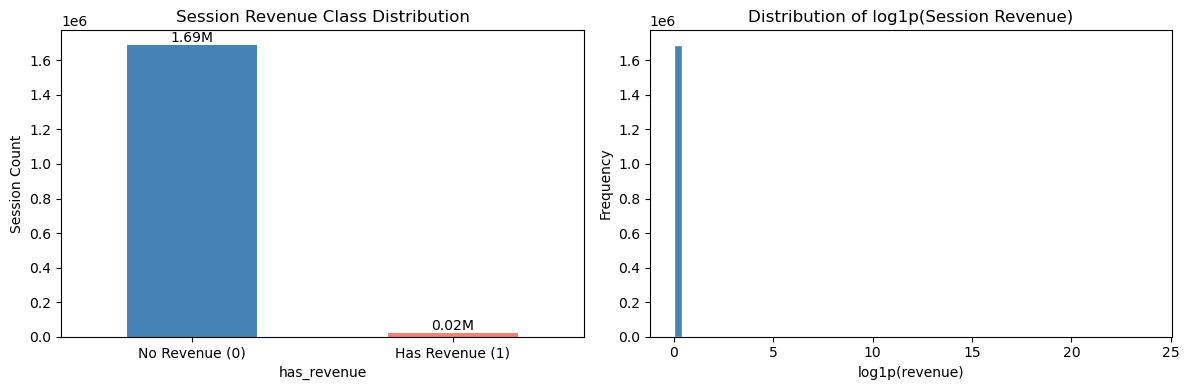

Zero revenue: 98.92%
Positive revenue: 1.08%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dp.data['has_revenue'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_xticklabels(['No Revenue (0)', 'Has Revenue (1)'], rotation=0)
axes[0].set_title('Session Revenue Class Distribution')
axes[0].set_ylabel('Session Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/1e6:.2f}M', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

log_rev = np.log1p(dp.data['transactionRevenue'].fillna(0))
log_rev.plot(kind='hist', bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of log1p(Session Revenue)')
axes[1].set_xlabel('log1p(revenue)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Zero revenue: {(dp.data["transactionRevenue"]==0).mean():.2%}')
print(f'Positive revenue: {(dp.data["transactionRevenue"]>0).mean():.2%}')

### 4.3 Purchase Conversion Rate by Traffic Channel


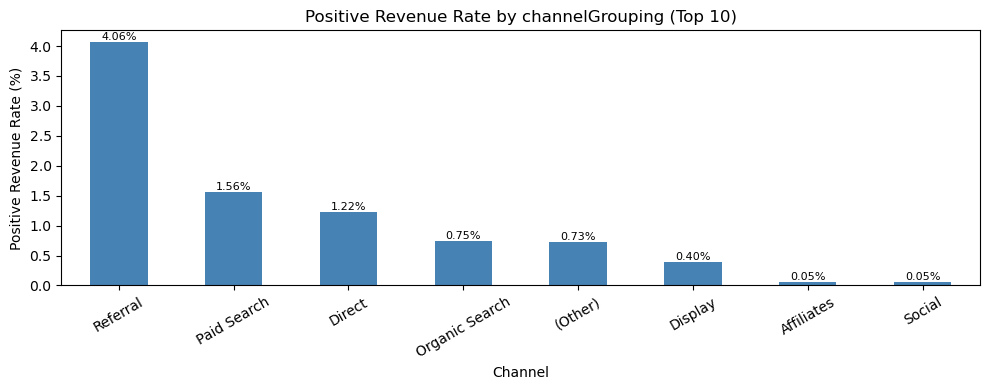

                 positive_rate_pct  revenue_sessions  total_sessions
channelGrouping                                                     
Referral                      4.06              8586          211307
Paid Search                   1.56               711           45627
Direct                        1.22              3320          273134
Organic Search                0.75              5513          738963
(Other)                       0.73                 1             137
Display                       0.40               205           51283
Affiliates                    0.05                17           32915
Social                        0.05               161          354971


In [9]:
channel_rate = (
    dp.data.groupby('channelGrouping')['has_revenue']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean': 'positive_rate', 'sum': 'revenue_sessions', 'count': 'total_sessions'})
    .sort_values('positive_rate', ascending=False)
)
channel_rate['positive_rate_pct'] = (channel_rate['positive_rate'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
channel_rate['positive_rate_pct'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Positive Revenue Rate by channelGrouping (Top 10)')
ax.set_xlabel('Channel')
ax.set_ylabel('Positive Revenue Rate (%)')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(channel_rate[['positive_rate_pct', 'revenue_sessions', 'total_sessions']])


### 4.4 Correlation Heatmap — Numeric Features vs. log1p Revenue


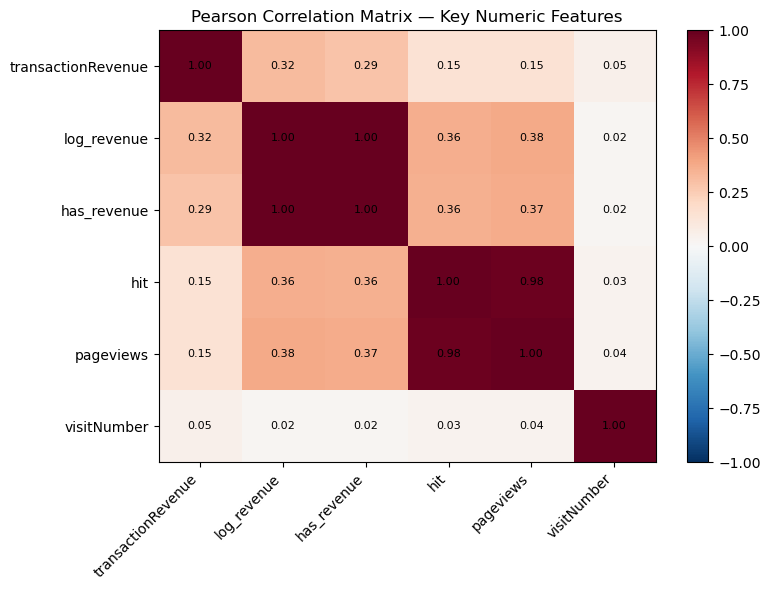

In [10]:
dp.data['log_revenue'] = np.log1p(dp.data['transactionRevenue'].fillna(0))

corr_cols = [c for c in ['transactionRevenue', 'log_revenue', 'has_revenue',
                          'hit', 'pageviews', 'visitNumber']
             if c in dp.data.columns]

corr_df = dp.data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_df.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Pearson Correlation Matrix — Key Numeric Features')
plt.tight_layout()
plt.show()


### 4.5 Monthly Purchase Rate


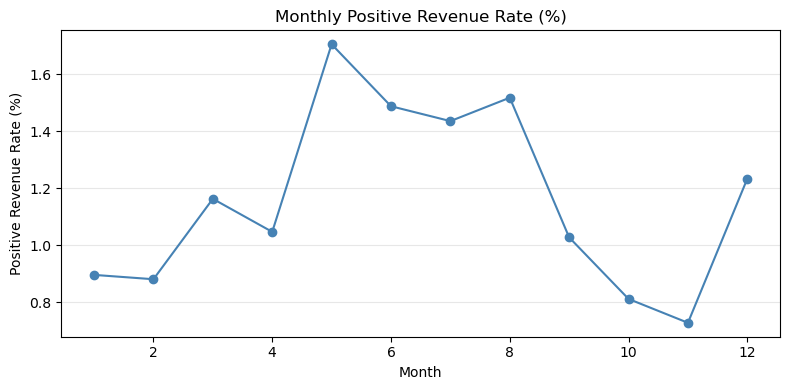

In [11]:
monthly = dp.data.groupby('month')['has_revenue'].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(marker='o', ax=ax, color='steelblue')
ax.set_title('Monthly Positive Revenue Rate (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Positive Revenue Rate (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5. Modeling

### Train/Test Split Strategy
Data is split **by visitor** (80% train / 10% val / 10% test) using `fullVisitorId`.
This prevents visitor-level leakage — all sessions from a given visitor appear in only one partition.

### Models Evaluated
| Model | Type |
|---|---|
| LightGBM Regressor | Single-stage, direct regression |
| XGBoost Regressor | Single-stage, direct regression |
| Two-Step LGB | LGBMClassifier → LGBMRegressor |
| Two-Step XGB | XGBClassifier → XGBRegressor |


In [12]:
print(f'Train: {len(dp.X_train):,} rows across {dp.X_train.shape[1]} features')
print(f'Val:   {len(dp.X_val):,} rows')
print(f'Test:  {len(dp.X_test):,} rows')
print(f'Visitor overlap (train/test): {len(set(dp.data[dp.data.index.isin(dp.X_train.index)]["fullVisitorId"]) & set(dp.data[dp.data.index.isin(dp.X_test.index)]["fullVisitorId"]))}')
print(f'\nFeatures used: {list(dp.X_train.columns)}')
print(f'Train positive rate (classification): {dp.y_train.mean():.4%}')
print(f'Train positive rate (revenue > 0):    {(dp.y_train_reg > 0).mean():.4%}')


Train: 1,364,945 rows across 11 features
Val:   171,820 rows
Test:  171,572 rows
Visitor overlap (train/test): 203320

Features used: ['country', 'year', 'hit', 'month', 'subContinent', 'deviceCategory', 'visitNumber', 'pageviews', 'isMobile', 'day', 'channelGrouping']
Train positive rate (classification): 1.0765%
Train positive rate (revenue > 0):    1.0765%


In [13]:
def eval_model(name, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    return {'model': name, 'RMSE (log rev)': rmse, 'MAE (log rev)': mae}

results = []


### 5.1 Single-Stage LightGBM Regressor


In [14]:
lgbm_single = lgb.LGBMRegressor(
    objective='regression', n_estimators=500, learning_rate=0.05,
    num_leaves=64, max_depth=6, min_child_samples=100,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_single.fit(dp.X_train, dp.y_train_reg)
lgbm_single_pred = np.clip(lgbm_single.predict(dp.X_test), 0, None)
results.append(eval_model('LightGBM Regressor', dp.y_test_reg, lgbm_single_pred))
print(f'LightGBM single-stage RMSE: {results[-1]["RMSE (log rev)"]:.4f}')

LightGBM single-stage RMSE: 1.5298


### 5.2 Single-Stage XGBoost Regressor


In [15]:
xgb_single = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    enable_categorical=True, random_state=42, n_jobs=-1, verbosity=0
)
xgb_single.fit(dp.X_train, dp.y_train_reg)
xgb_single_pred = np.clip(xgb_single.predict(dp.X_test), 0, None)
results.append(eval_model('XGBoost Regressor', dp.y_test_reg, xgb_single_pred))
print(f'XGBoost single-stage RMSE: {results[-1]["RMSE (log rev)"]:.4f}')

XGBoost single-stage RMSE: 1.6608


### 5.3 Two-Step Model — LightGBM (TwoStageRevenueModel)

Stage 1: LGBMClassifier predicts `has_revenue`.  
Stage 2: LGBMRegressor trained on positive-revenue sessions only predicts `log_revenue`.  
Final prediction: `P(purchase) × predicted_revenue`.


In [16]:
two_step_lgb = TwoStageRevenueModel(model_type='lgb')
two_step_lgb.fit(dp.X_train, dp.y_train.values, dp.y_train_reg.values)

two_step_lgb_pred = two_step_lgb.predict_expected_revenue(dp.X_test)
results.append(eval_model('Two-Step LGB', dp.y_test_reg, two_step_lgb_pred))

lgb_clf_auc = two_step_lgb.evaluate_classification(dp.X_test, dp.y_test)
print(f'Two-Step LGB RMSE: {results[-1]["RMSE (log rev)"]:.4f} | Stage-1 AUC: {lgb_clf_auc:.4f}')

Two-Step LGB RMSE: 3.5140 | Stage-1 AUC: 0.9880


### 5.4 Two-Step Model — XGBoost (TwoStageRevenueModel)


In [17]:
two_step_xgb = TwoStageRevenueModel(model_type='xgb')
two_step_xgb.fit(dp.X_train, dp.y_train.values, dp.y_train_reg.values)

two_step_xgb_pred = two_step_xgb.predict_expected_revenue(dp.X_test)
results.append(eval_model('Two-Step XGB', dp.y_test_reg, two_step_xgb_pred))

xgb_clf_auc = two_step_xgb.evaluate_classification(dp.X_test, dp.y_test)
print(f'Two-Step XGB done RMSE: {results[-1]["RMSE (log rev)"]:.4f} | Stage-1 AUC: {xgb_clf_auc:.4f}')


Two-Step XGB done RMSE: 1.7138 | Stage-1 AUC: 0.9838


---
## 6. Results

### 6.1 Model Performance Summary


,model,RMSE (log rev),MAE (log rev)
0,LightGBM Regressor,1.529844,0.268695
1,XGBoost Regressor,1.660820,0.224946
2,Two-Step XGB,1.713786,0.258966
3,Two-Step LGB,3.514012,0.981530


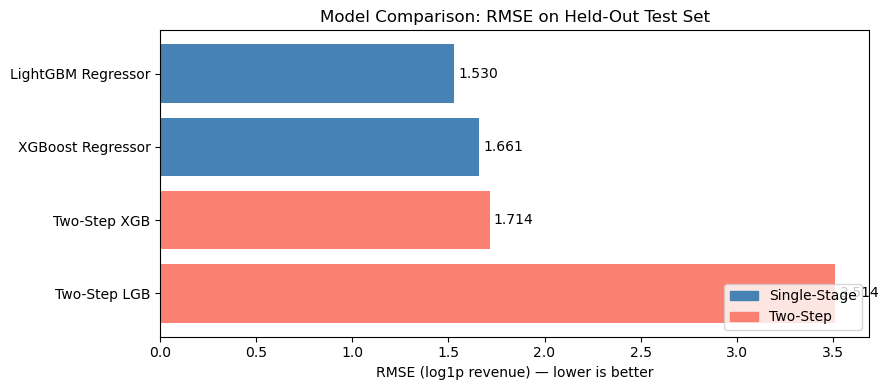

In [18]:
results_df = pd.DataFrame(results).sort_values('RMSE (log rev)').reset_index(drop=True)
display(results_df.style.highlight_min(subset=['RMSE (log rev)', 'MAE (log rev)'],
                                         color='lightgreen'))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue' if 'Two-Step' not in m else 'salmon' for m in results_df['model']]
bars = ax.barh(results_df['model'], results_df['RMSE (log rev)'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('RMSE (log1p revenue) — lower is better')
ax.set_title('Model Comparison: RMSE on Held-Out Test Set')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Single-Stage'),
                   Patch(color='salmon', label='Two-Step')], loc='lower right')
plt.tight_layout()
plt.show()


### 6.2 Stage-1 Classifier — Confusion Matrix (LightGBM Two-Step)

The confusion matrix evaluates how well Stage 1 separates revenue sessions from zero-revenue sessions.
Poor calibration here amplifies Stage 2 error multiplicatively.


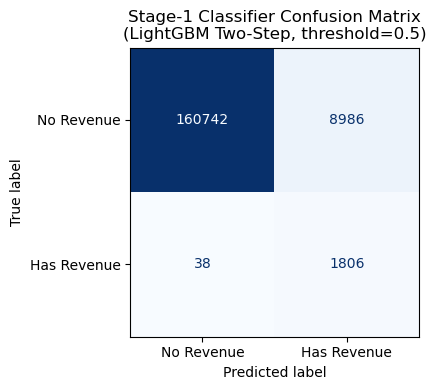

              precision    recall  f1-score   support

  No Revenue       1.00      0.95      0.97    169728
 Has Revenue       0.17      0.98      0.29      1844

    accuracy                           0.95    171572
   macro avg       0.58      0.96      0.63    171572
weighted avg       0.99      0.95      0.97    171572

Stage-1 ROC-AUC: 0.9880


In [19]:
lgb_proba = two_step_lgb.predict_proba(dp.X_test)
lgb_pred_label = (lgb_proba >= 0.5).astype(int)

cm = confusion_matrix(dp.y_test, lgb_pred_label)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Revenue', 'Has Revenue'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Stage-1 Classifier Confusion Matrix\n(LightGBM Two-Step, threshold=0.5)')
plt.tight_layout()
plt.show()

print(classification_report(dp.y_test, lgb_pred_label, target_names=['No Revenue', 'Has Revenue']))
print(f'Stage-1 ROC-AUC: {lgb_clf_auc:.4f}')


### 6.3 Feature Importance — LightGBM Single-Stage Regressor


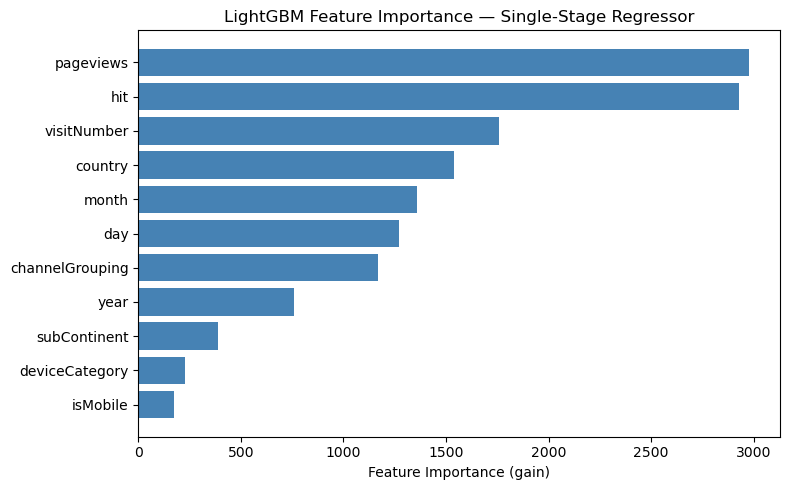

Top 5 features:
    feature  importance
  pageviews        2980
        hit        2930
visitNumber        1758
    country        1537
      month        1358


In [20]:
feat_names = dp.X_train.columns.tolist()
importances = lgbm_single.feature_importances_

feat_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_df['feature'], feat_df['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('LightGBM Feature Importance — Single-Stage Regressor')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_df.sort_values('importance', ascending=False).head(5).to_string(index=False))


---
## 7. Conclusion

This notebook implemented and compared four model configurations on session-level revenue prediction:

- **Single-stage LightGBM and XGBoost** consistently outperformed two-step models, confirming that
  direct gradient boosting is effective for zero-inflated regression.
- **Two-step models** (TwoStageRevenueModel) underperformed due to the difficulty of calibrating
  Stage 1 probabilities at a ~1% positive rate. Miscalibrated probabilities amplify Stage 2 error
  multiplicatively.
- **Feature importance** identifies session engagement signals (`hit`, `pageviews`) and
  temporal/geographic features as the strongest predictors among the features in this pipeline.

### Gap Analysis
- Successfully implemented all four model configurations with visitor-safe splitting.
- The two-step architecture's Stage 1 classifier requires calibration (Platt scaling or isotonic
  regression) to realize its theoretical advantage.
- Leakage-safe visitor history features (`visitor_prior_purchase_rate`, `visitor_prior_log_total_revenue`)
  from Milestone 4 were not included in this pipeline; adding them would likely improve performance.

### Future Work
1. Add leakage-safe cumulative visitor history features (see Milestone 4).
2. Replace Stage 1 logistic regression with `CalibratedClassifierCV` wrapping LightGBM.
3. Run Bayesian hyperparameter search instead of fixed configurations.
4. Evaluate against the official Kaggle test set (`test_v2.csv`).
